In [9]:
from pathlib import Path

from astropy.io import fits
from astropy.io.fits.fitsrec import FITS_rec
from numpy.typing import NDArray
import numpy as np
from scipy.interpolate import griddata

from bloodmoon.coords import angle2shift
from bloodmoon.mask import CodedMaskCamera, codedmask

import darksun as ds
from darksun.benchmarking import source_catalogue_data

ds.show.set_figures_darkbkg()

In [10]:
def load_fits_data(path: Path, ext: int = 1) -> FITS_rec:
    """Loads the FITS file data from chosen extension."""
    return fits.getdata(path, ext=ext, header=False)

def interp(
    x: NDArray,
    y: NDArray,
    energy: NDArray,
) -> NDArray:
    """Interpolates `y` values in given `energy` values."""
    return griddata(x, y, energy, method='linear')

def local2polar(theta_x: float, theta_y: float) -> float:
    """
    Computes the polar angular coord wrt to the xy plane.
    Both `theta_x` and `theta_y` are in [deg].
    Output angle value is in [deg].
    """
    tan_x, tan_y = map(
        lambda x: np.tan(np.deg2rad(x)), (theta_x, theta_y),
    )
    return np.rad2deg(np.atan(np.sqrt(tan_x ** 2 + tan_y ** 2)))

In [11]:
def _config_hist_values(
    x: NDArray,
    y: NDArray,
    interval: tuple[float, float],
) -> tuple[NDArray, NDArray]:
    """
    Extract `x` values in the `interval` range and respective
    values for `y`. Since x represents a binning array, len(x)
    must be equal to len(y) + 1.
    """
    low, high = interval
    band: NDArray = np.where((x >= low) & (x <= high))[0]
    return x[band], y[band[:-1]]

def extract_spectrum(
    data: FITS_rec,
    sourceID: str,
    energy_range: tuple[float, float] = (2.0, 50.0),
) -> tuple[NDArray, NDArray]:
    """
    Extracts source energy bins and spectrum values in specified `energy_range`.
    """
    data_: FITS_rec = source_catalogue_data(sourceID, data)
    energy, spectrum = _config_hist_values(
        data_['ENERGY'], data_['SPECTRUM'], energy_range,
    )
    return energy, spectrum

def integrate_spectrum(
    spectrum: NDArray,
    energy_bins: NDArray,
) -> float:
    """
    Integrates a source spectrum wrt input energy_bins to compute
    the average flux in [ph/cm2/s] in the given energy range.
    """
    # - energy values are considered as bins, so we have:
    #   len(energy_bins) = len(spectrum) + 1
    return np.sum(spectrum * np.diff(energy_bins))

In [12]:
# directory path
# base_path: str = "/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations"
base_path: str = "/mnt/d/PhD_AASS/Coding/Images_fits"

# load camera framework
MASK_FITS: str = "mask_NTHT_20260129_CORRECTED.fits"
UPS_X, UPS_Y = 5, 1
wfm: CodedMaskCamera = codedmask(f'{base_path}/{MASK_FITS}', UPS_X, UPS_Y)

# files paths
settings_path: str = f"{base_path}/camera_settings"
catalogue_path: Path = Path(settings_path, "RXTE-ASM_BeppoSAX-WFC_catalog_new_2-50keV.fits")
detSi_matten_path: Path = Path(settings_path, "detectorSi_absrp.fits")
detBe_dl_filter_path: Path = Path(settings_path, "detectorBe_deadlayer_filter.fits")
maskKapton_mli_path: Path = Path(settings_path, "mask_MLI_Kapton.fits")

- Let's extract from the BeppoSAX-WFC catalogue the energy values at which the sources spectra are computed

Energy range: (2.0, 50.0) keV
  - Source avg flux:     2.7000 ph/cm2/s
  - Source fluence:   2699.9998 ph/cm2



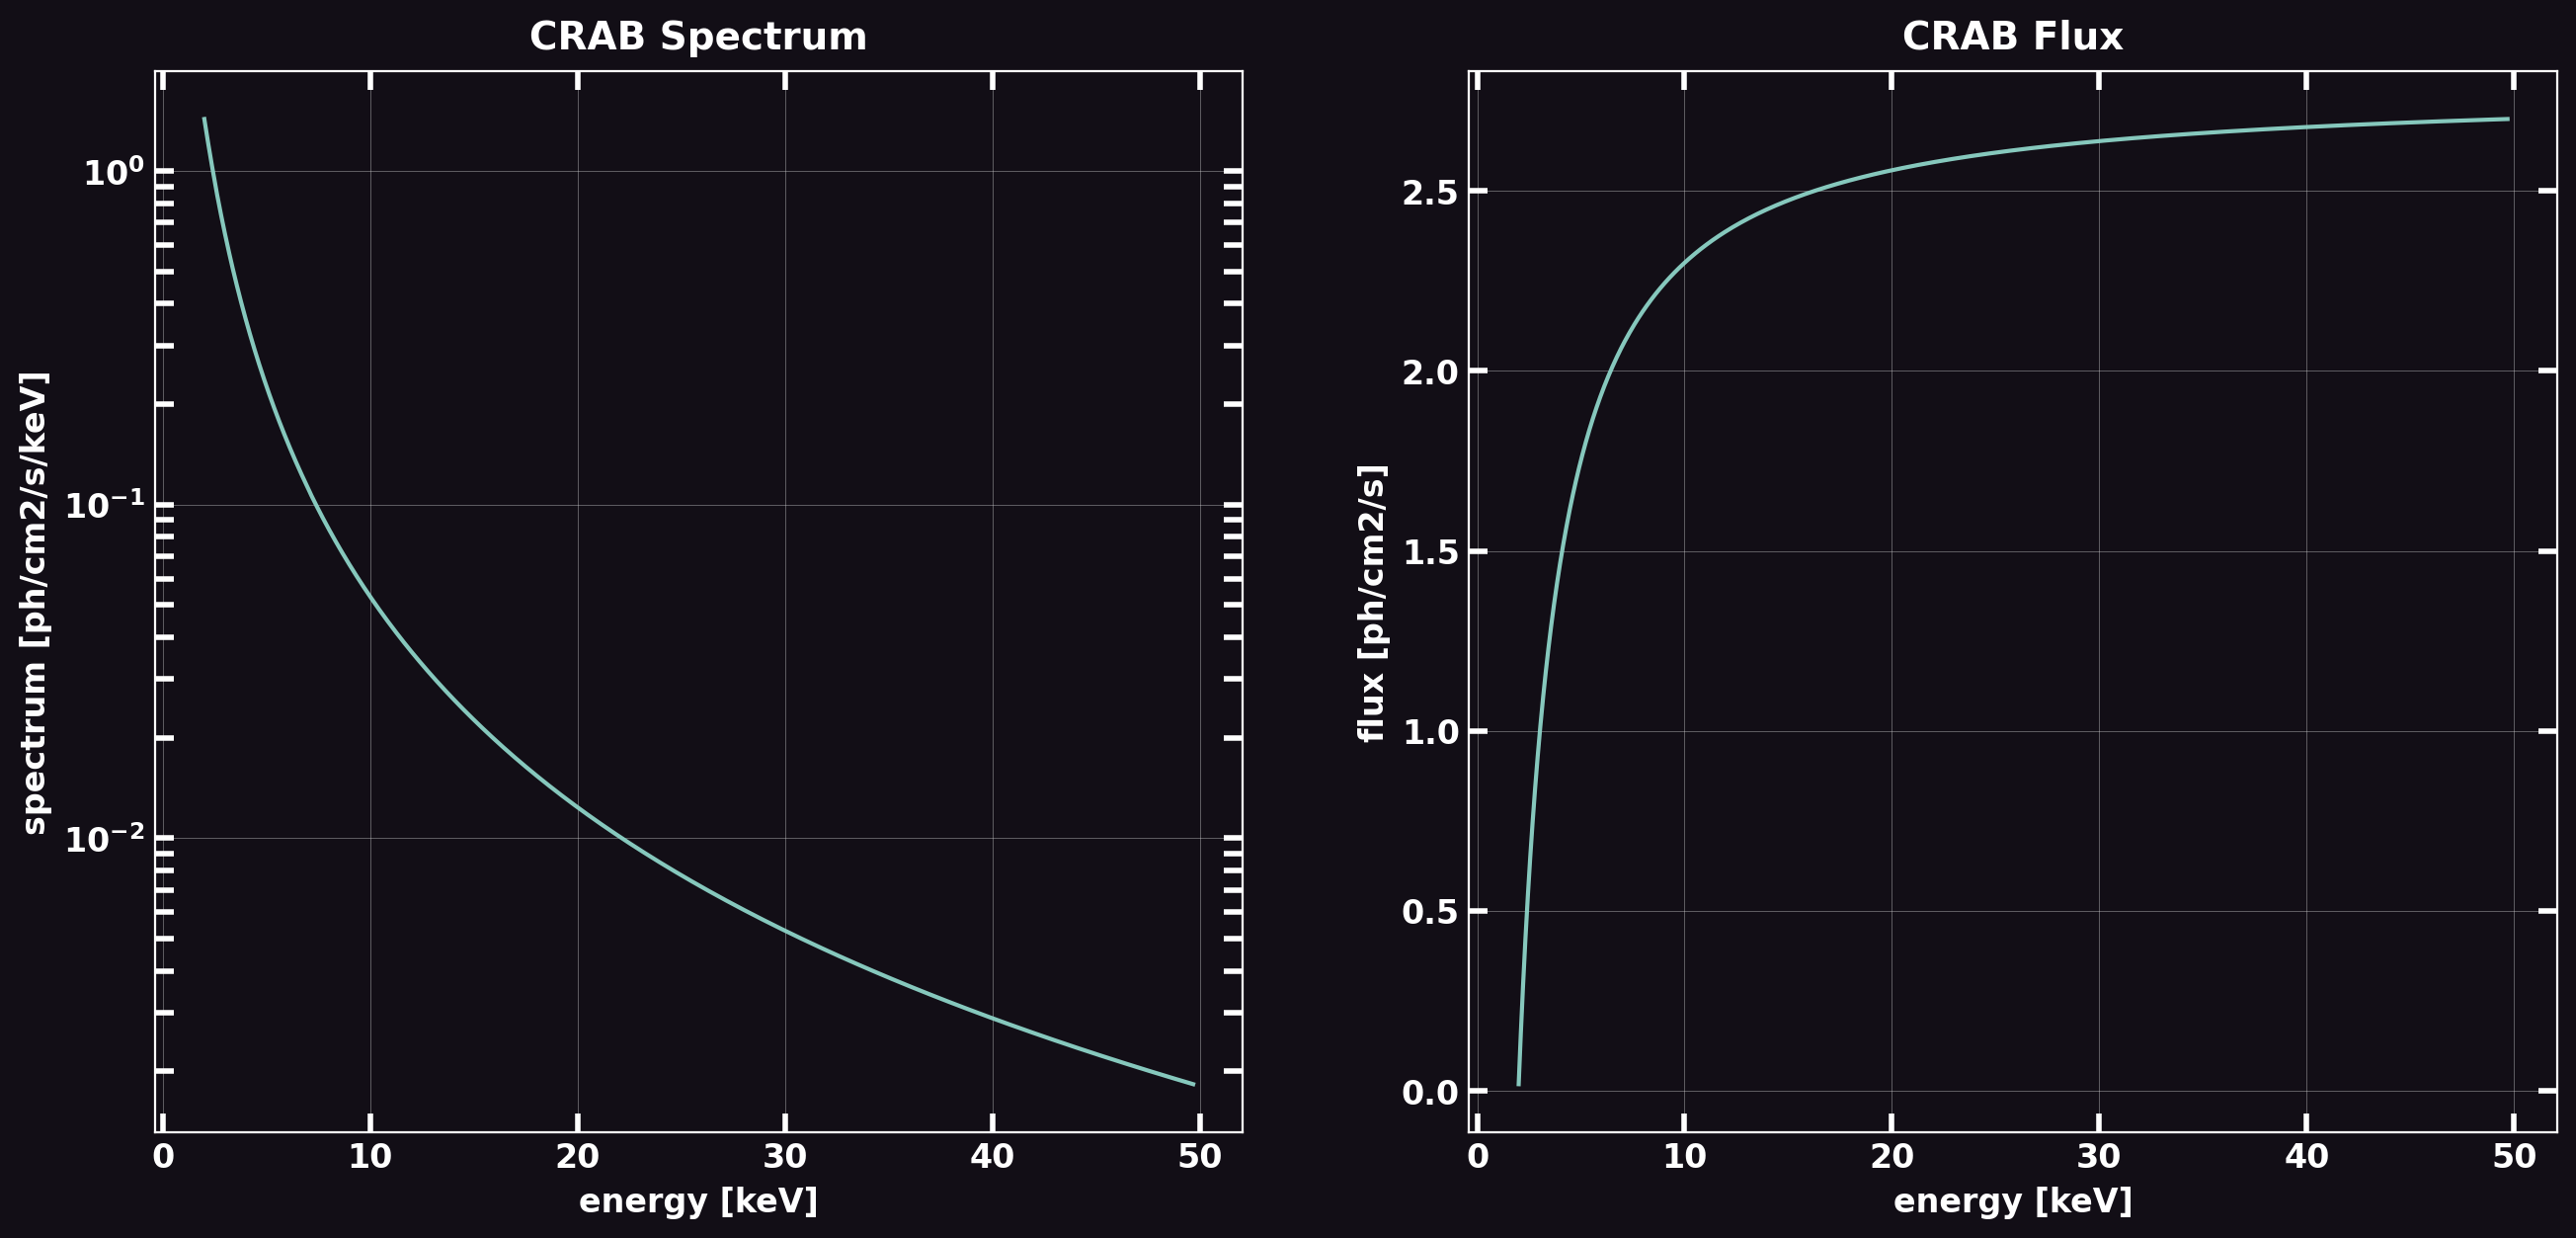

In [13]:
catalogue: FITS_rec = load_fits_data(catalogue_path)

sourceID: str = 'crab'                              # source ID in the record
energy_range: tuple[float, float] = (2.0, 50.0)     # specifies photons energy range [keV]

energy, spectrum = extract_spectrum(catalogue, sourceID, energy_range)
avg_flux: float = integrate_spectrum(spectrum, energy)  # [ph/cm2/s]
exposure: float = 1e3                                   # [s]

print(
    f'Energy range: {energy_range} keV\n'
    f'  - Source avg flux:  {' ' * int(np.log10(exposure))}{avg_flux:.4f} ph/cm2/s\n'
    f'  - Source fluence:   {avg_flux * exposure:.4f} ph/cm2\n'
)

if True:
    ds.plot(
        dmaps=(
            ds.map4plot(
                arrs=spectrum,
                title=f'{sourceID.upper()} Spectrum',
                x=energy[:-1],
                xlabel='energy [keV]',
                ylabel='spectrum [ph/cm2/s/keV]',
                yscale='log',
            ),
            ds.map4plot(
                arrs=np.cumsum(spectrum * np.diff(energy)),
                title=f'{sourceID.upper()} Flux',
                x=energy[:-1],
                xlabel='energy [keV]',
                ylabel='flux [ph/cm2/s]',
            ),
        ),
        ncols=2,
    )

- Let's now compute the coded-mask camera transfer function

In [14]:
def config_transmissions(energy: NDArray) -> tuple[NDArray, NDArray, NDArray]:
    """
    Extracts camera MLI and micro-meteoroid filter + detector
    dead layers transmission and detector mass attenuation
    values and interpolates them wrt the input energy values.
    """
    def extract_values(data: FITS_rec) -> tuple[NDArray, NDArray]:
        """Extracts photons energy and transmission values."""
        return data.field(0), data.field(1)

    # load camera and detector transmissions data
    detSi_matten: FITS_rec = load_fits_data(detSi_matten_path)
    detBe_dl_filter: FITS_rec = load_fits_data(detBe_dl_filter_path)
    maskKapton_mli: FITS_rec = load_fits_data(maskKapton_mli_path)
    # extract MLI, dead layer and meteoroid filter transmissions (ON-AXIS)
    _energy, _mli_transm = extract_values(maskKapton_mli)
    _, _dl_filter_transm = extract_values(detBe_dl_filter)
    # extract detector mass attenuation (ON-AXIS)
    _, _matten = extract_values(detSi_matten)  # [cm2/g]
    # interpolate values for array broadcasting
    mli_transm, dl_filter_transm, matten = map(
        lambda y: interp(_energy, y, energy)[:-1],
        (_mli_transm, _dl_filter_transm, _matten),
    )
    return mli_transm, dl_filter_transm, matten

def get_detector_QE(
    matten: NDArray,
    angle: float,
) -> NDArray:
    """
    Computes detector absorption probability wrt energy and
    direction. The mass attenuation values are in [cm2/g],
    angle in [rad] (polar angle wrt camera plane).
    """
    rho: float = 2.33   # [g/cm3] (from FITS header)
    d: float = 0.045    # [cm]
    return 1.0 - np.exp(-rho * matten * d / np.cos(angle))

def get_instr_transfer_func(
    mli_transmission: NDArray,
    dl_transmission: NDArray,
    matten: NDArray,
    coords: tuple[float, float],
) -> NDArray:
    """
    Computes LEM-X camera instrumental transfer function for a photon in given
    energy band (selected in the transmissions) and from given direction, taking
    into account the camera MLI layers, the micro-meteoroid filter, the detector
    dead layers and Si-based plates.
    """
    polar_angle: float = np.deg2rad(local2polar(*coords))
    # compute MLI and filter/dead layers transmissions (OFF-AXIS)
    trans: NDArray = (
        np.pow(mli_transmission * dl_transmission, 1 / np.cos(abs(polar_angle)))
    )
    # compute detector QE (OFF-AXIS)
    detector_qe: NDArray = get_detector_QE(matten, abs(polar_angle))
    return trans * detector_qe

In [15]:
from typing import Callable
from bloodmoon.optim import _detector_footprint_cached
from flexible_source_model import _shift_mask_pattern, _process_mask_pattern

def get_effective_area(
    camera: CodedMaskCamera,
    shift_x: float,
    shift_y: float,
    vignetting: bool | Callable = True,
) -> float:
    """
    Computes the source effective area on detector in [cm^2].

    Args:
        camera (CodedMaskCamera):
            Instance with camera geometry info.
        shift_x (float):
            Source coord along fine direction in camera local-frame system.
        shift_y (float):
            Source coord along coarse direction in camera local-frame system.
        vignetting (bool, optional (default=`True`)):
            If `True`, the source model will simulate mask vignetting effects.
    
    Returns:
        output (float):
            Source effective area value on detector in [cm^2].
    """
    # pixel area in [cm^2]
    pixel_area: float = (
        1e-2 * camera.specs.mask_deltax * camera.specs.mask_deltay / np.prod(camera.upscale_f)
    )
    # mask pattern projection WTO detector sp. res.
    # - shift camera mask pattern wrt source local-frame coords
    sg = _shift_mask_pattern(camera, shift_x, shift_y)
    # - apply instrumental effects
    sg = _process_mask_pattern(
        camera, sg, shift_x, shift_y, vignetting, False,
    )
    # extract detector
    i_min, i_max, j_min, j_max = _detector_footprint_cached(camera)
    detector = sg[i_min:i_max, j_min:j_max]
    detector *= camera.bulk
    return detector.sum() * pixel_area


def compute_source_counts(
    camera: CodedMaskCamera,
    coords: tuple[float, float],
    flux: float,
    exposure: float,
    vignetting: bool = True,
) -> int:
    """
    Computes source counts given its average flux. Input coords
    are in [deg], flux in [ph/cm2/s], and exposure is in [s].
    """
    coords_ = map(lambda x: angle2shift(camera, x), coords)
    eff_area = get_effective_area(camera, *coords_, vignetting)
    return int(flux * eff_area * exposure)

In [16]:
type AngularCoords = tuple[float, float]   # camera local-frame angular coords (fine, coarse) in [deg]
type EnergyRange = tuple[float, float]     # photons energy range (min, max) in [keV]

def plot_spectr(
    sourceID: str,
    coords: AngularCoords,
    energy_bins: NDArray,
    spectrum: NDArray,
    transfunc: NDArray,
    mli: NDArray,
    dl_filter: NDArray,
    matten: NDArray,
) -> None:
    """Plots source spectrum and instr. modulations."""
    polar_angle = np.deg2rad(local2polar(*coords))
    exp = 1 / np.cos(polar_angle)
    det_qe = get_detector_QE(
        matten=matten,
        angle=polar_angle,
    )
    ds.plot(
        dmaps=(
            ds.map4plot(
                arrs=(spectrum, transfunc * spectrum),
                title=f'{sourceID.upper()} Spectrum',
                x=energy_bins[:-1],
                xlabel='energy [keV]',
                ylabel='spectrum [ph/cm$^{2}$/s/keV]',
                labels=('Emitted', 'Modulated'),
                yscale='log',
                xscale='log',
            ),
            ds.map4plot(
                arrs=(
                    np.pow(mli, exp), np.pow(dl_filter, exp), det_qe, transfunc,
                ),
                title='Transmissions',
                x=energy_bins[:-1],
                xlabel='energy [keV]',
                ylabel='transmission',
                labels=(
                    'MLI', 'Mfilter + dead lys', 'SDD QE', 'Instr. transfer func',
                ),
                xscale='log',
                yscale='log',
            ),
        ),
        ncols=2,
    )
    return None


def compute_instr_transfer_func(energy_bins: NDArray, coords: AngularCoords) -> NDArray:
    """Computes the coded-mask camera instr. transfer function."""
    mli, dl_filter, matten = config_transmissions(energy_bins)
    transfunc = get_instr_transfer_func(mli, dl_filter, matten, coords)
    return transfunc

def compute_source_avgflux(
    sourceID: str,
    energy_bins: NDArray,
    emitted_spectrum: NDArray,
    coords: AngularCoords,
    show_spectr: bool = False,
) -> float:
    """
    Computes the source average flux measured by a LEM-X camera in [ph/cm2/s].
    """
    # modulate source spectrum with instrumental transfer func
    transfunc = compute_instr_transfer_func(energy_bins, coords)
    # show spectrum plot
    if show_spectr:
        mli, dl_filter, matten = config_transmissions(energy_bins)
        plot_spectr(
            sourceID, coords, energy_bins, emitted_spectrum,
            transfunc, mli, dl_filter, matten,
        )
    return integrate_spectrum(transfunc * emitted_spectrum, energy_bins)

## **Crab Spectrum**

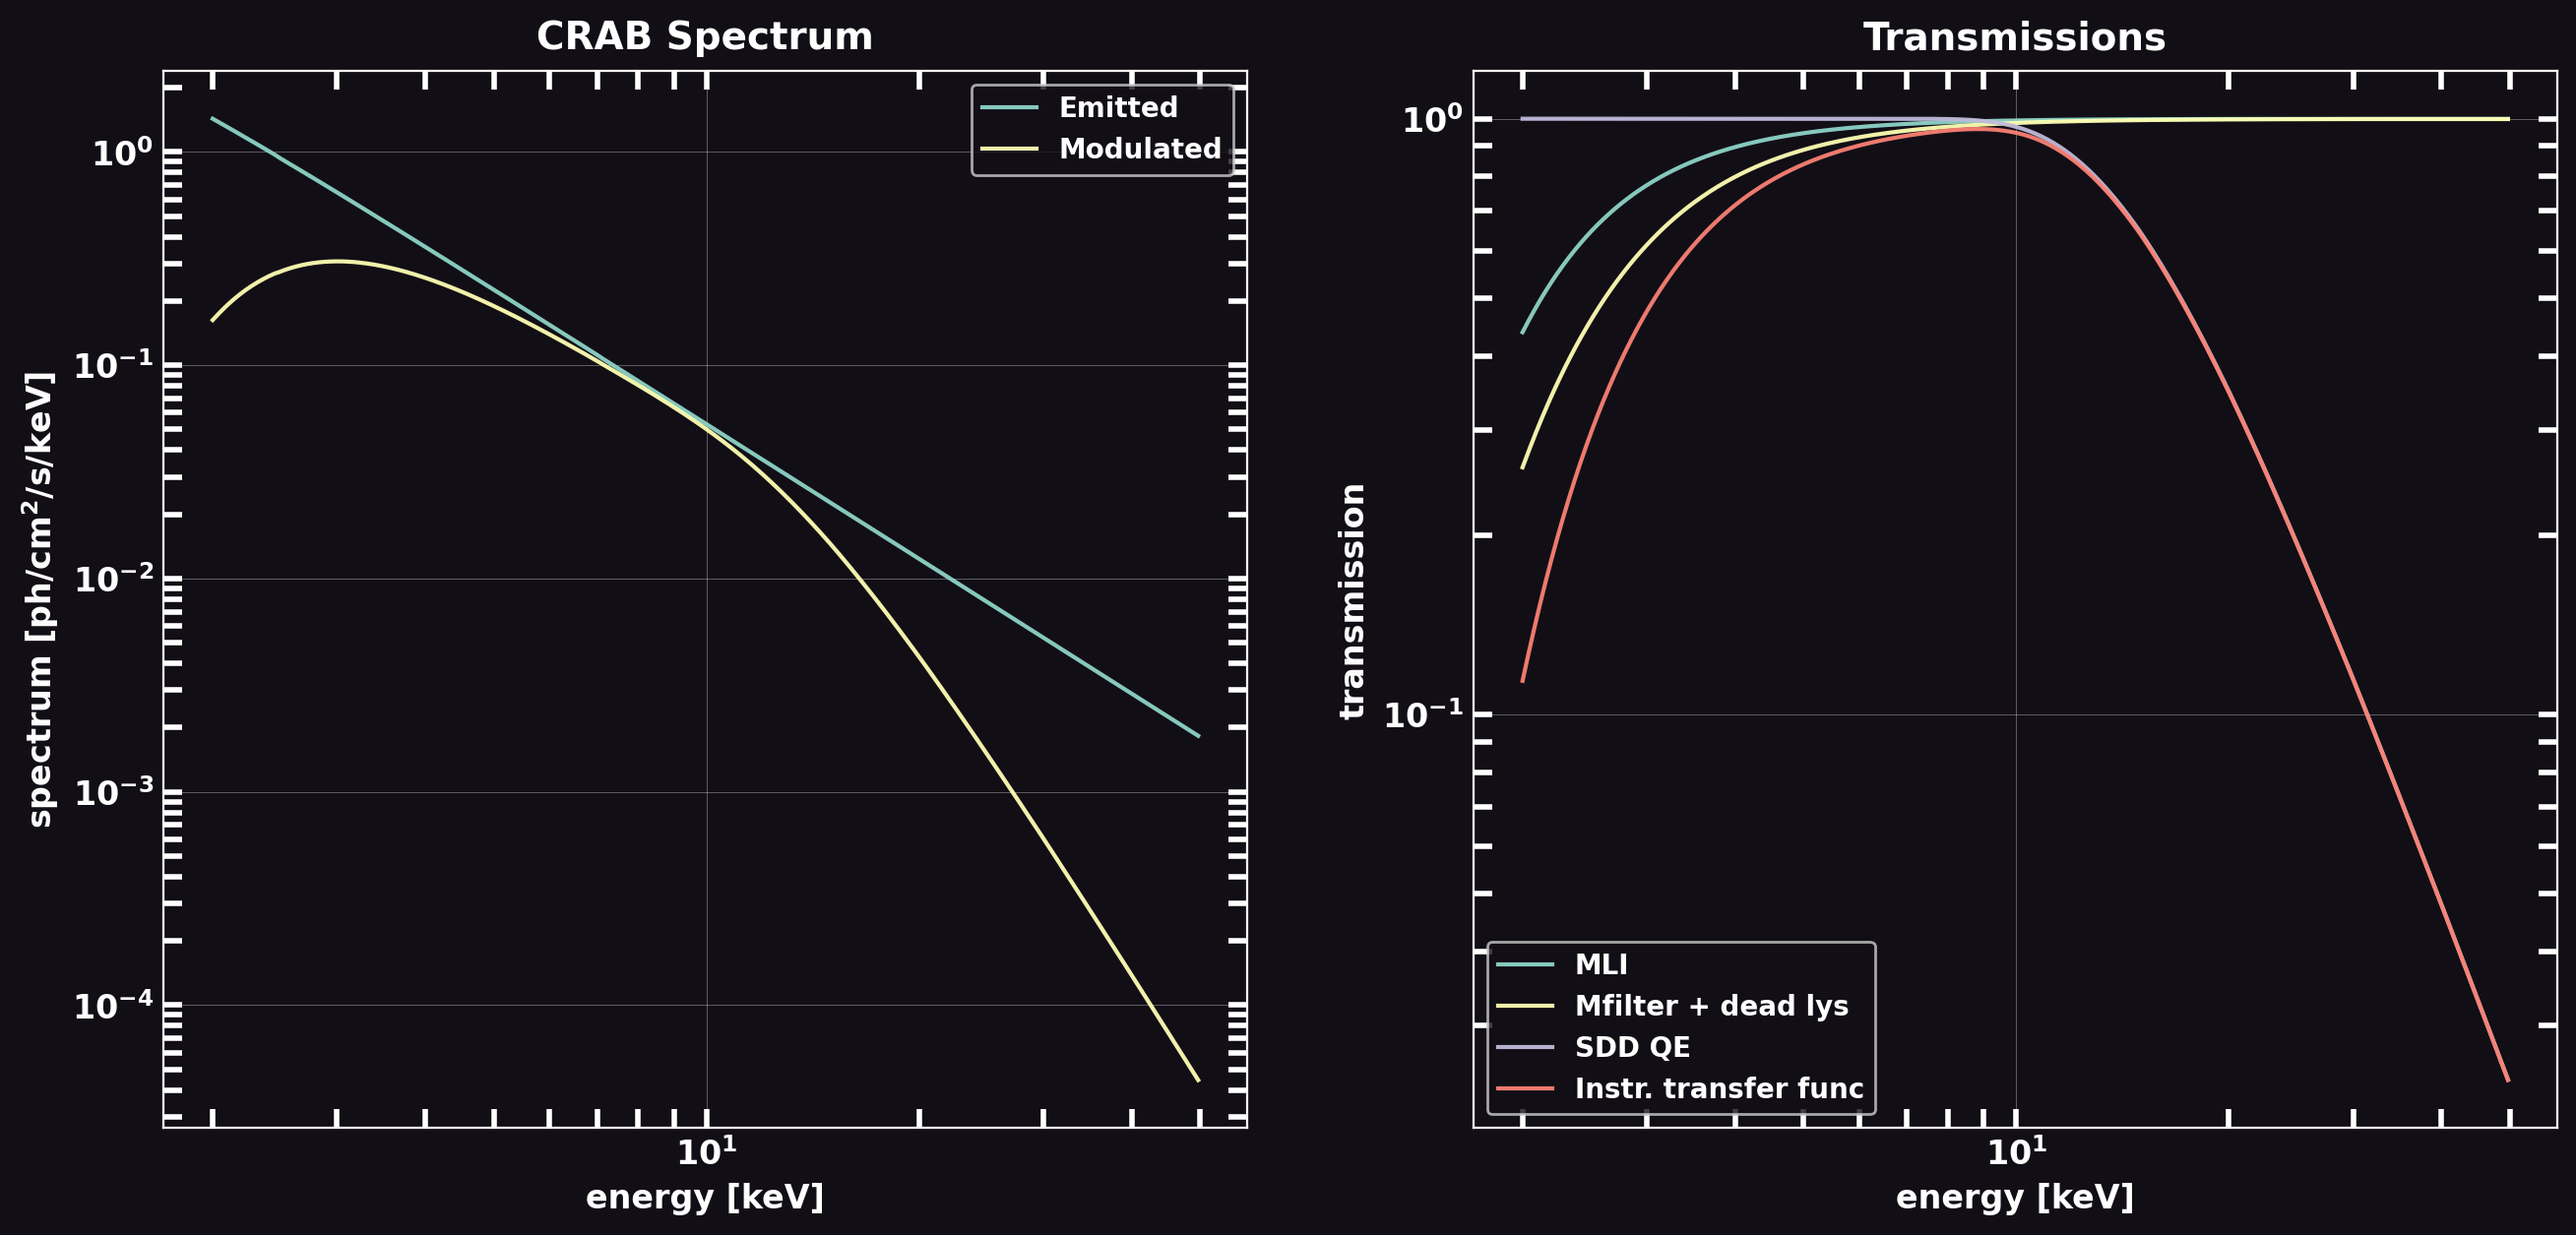

## USING BULK MASK with 1.5 mm cover ##
CRAB avg flux in (2.0, 50.0) keV: 2.7000 ph/cm2/s

Energy range: (2.0, 50.0) keV at (0.0, 0.0) deg
  - Source obs avg flux: 1.4898 ph/cm2/s
  - Source obs counts in 1.0 ks: 106066 +/- 325 ph



In [17]:
# init source info
sourceID: str = 'crab'                      # source ID
energy_range: EnergyRange = (2.0, 50.0)     # specifies photons energy range [keV]

coords: AngularCoords = (0.0, 0.0)     # [deg]
exposure: float = 1e3                  # [s]

energy_bins, emitted_spectrum = extract_spectrum(catalogue, 'crab', energy_range)
avg_flux: float = compute_source_avgflux(sourceID, energy_bins, emitted_spectrum, coords, True)   # [ph/cm2/s]
counts: int = compute_source_counts(wfm, coords, avg_flux, exposure)                                # [ph]
print(
    f'{sourceID.upper()} avg flux in {energy_range} keV: {integrate_spectrum(emitted_spectrum, energy_bins):.4f} ph/cm2/s\n'
)
print(
    f'Energy range: {energy_range} keV at {coords} deg\n'
    f'  - Source obs avg flux: {avg_flux:.4f} ph/cm2/s\n'
    f'  - Source obs counts in {exposure/1e3} ks: {counts} +/- {int(np.sqrt(counts))} ph\n'
)

## **Mock Emission Spectrum**

- First mock spectrum type: **FLAT OBSERVED CRAB SPECTRUM** (also to test if working properly)

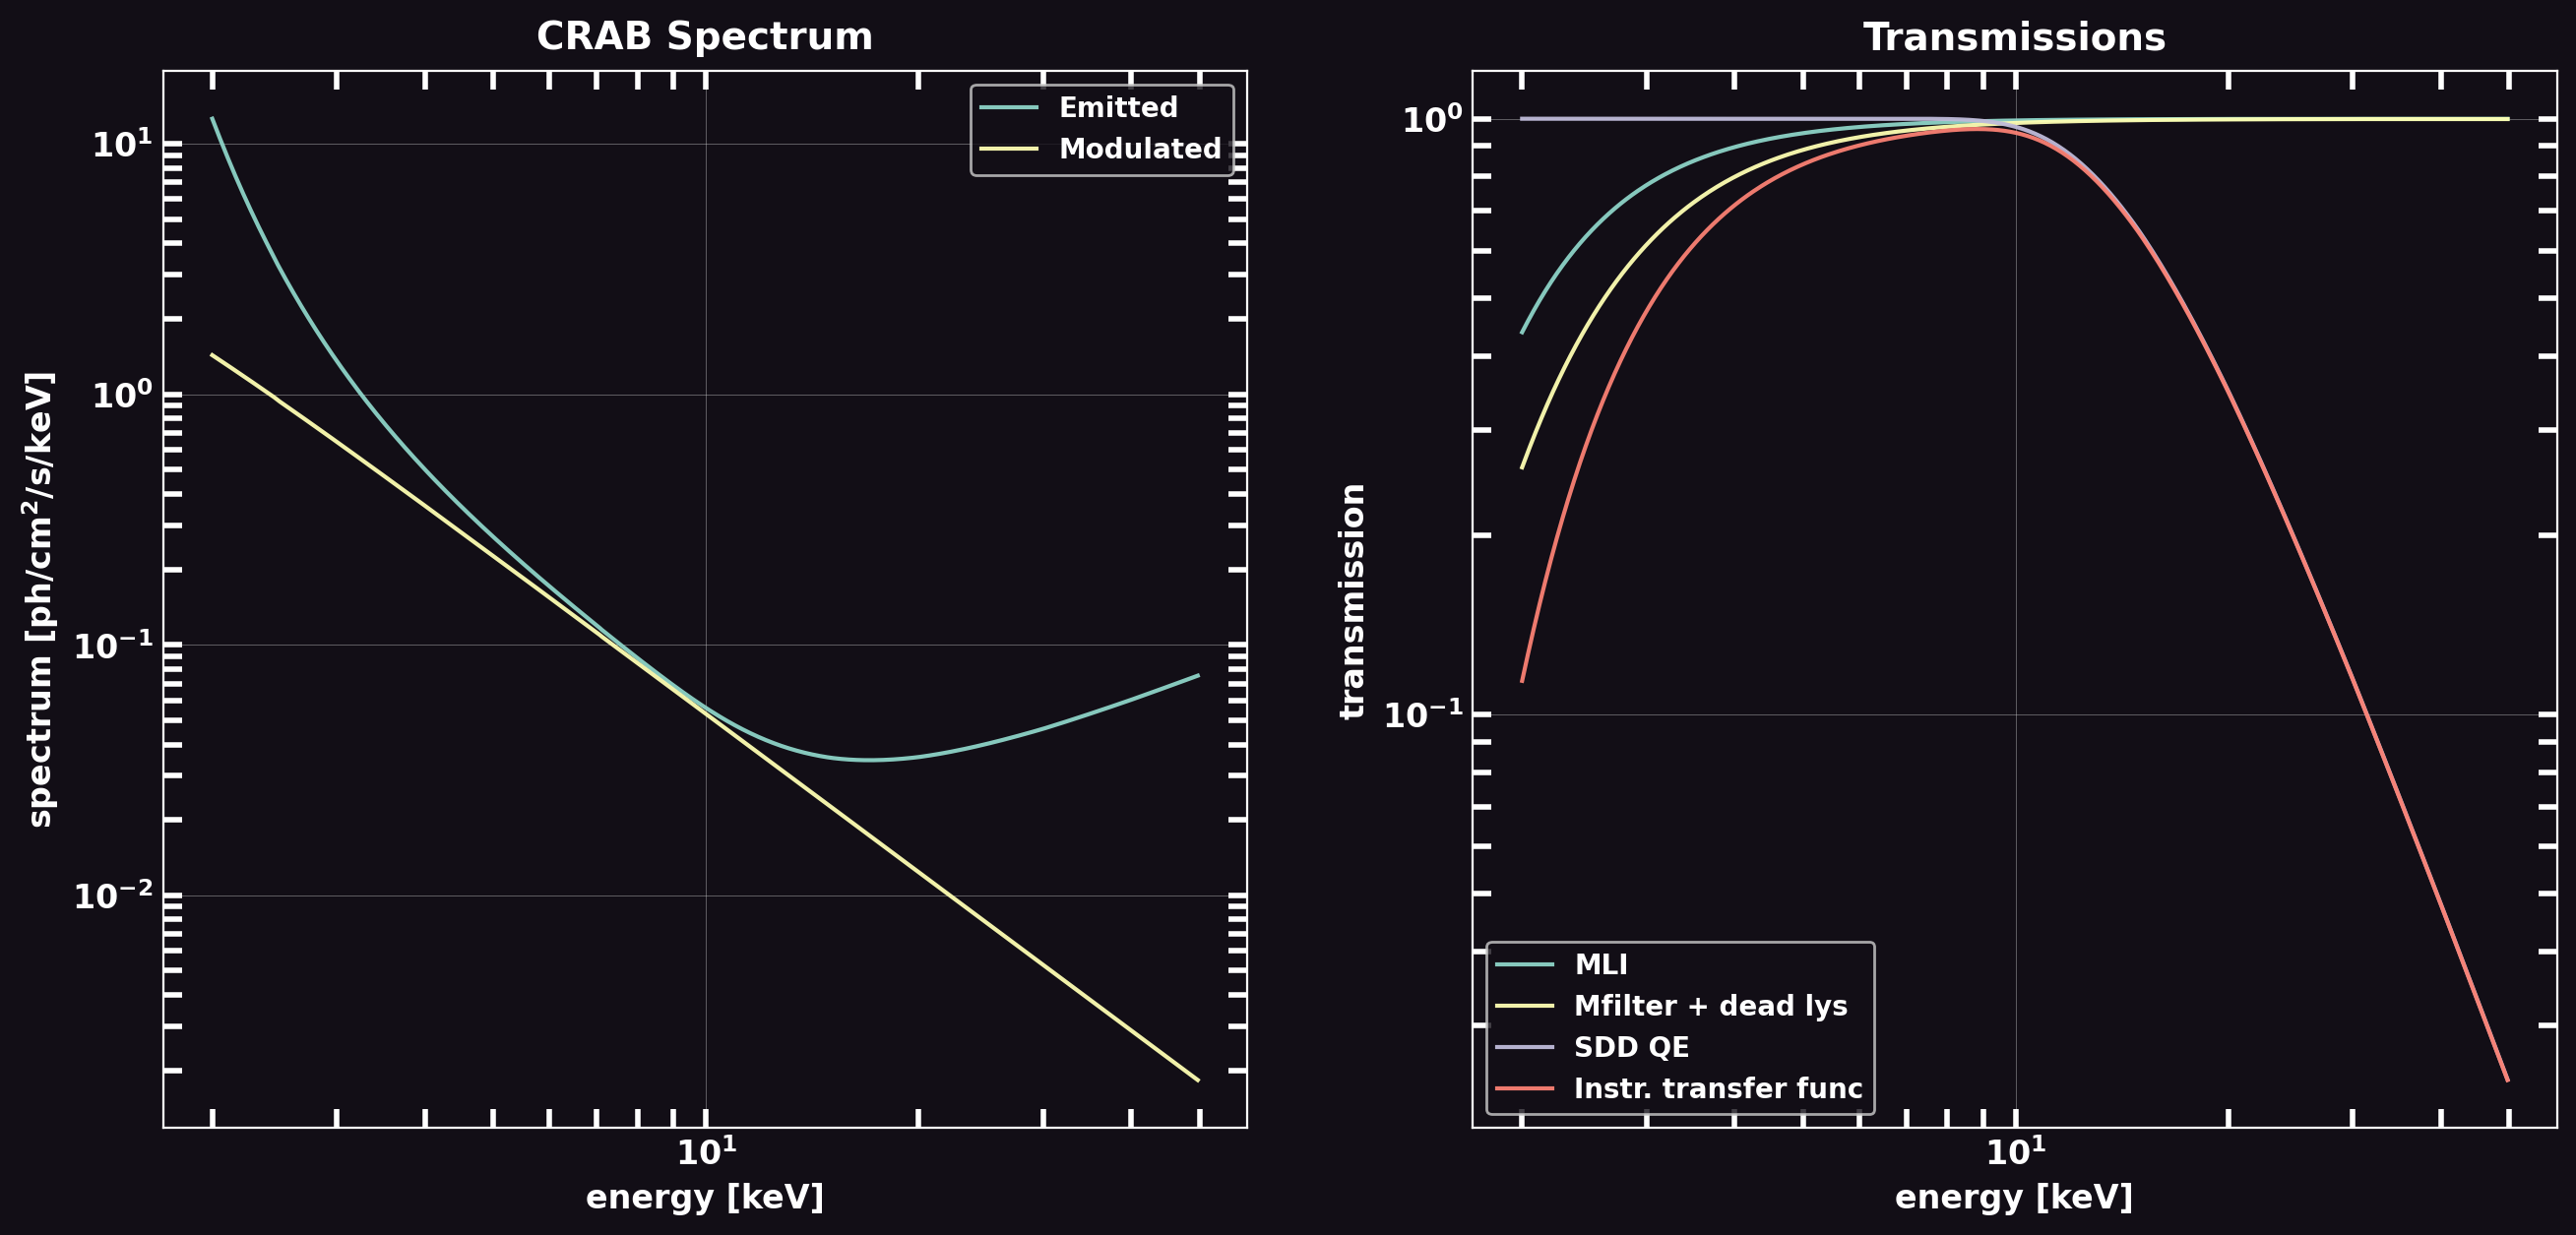

Input total flux: 2.9967 Crab

Energy range: (2.0, 50.0) keV at (0.0, 0.0) deg
  - Source obs avg flux: 2.7000 ph/cm2/s
  - Source obs counts in 1.0 ks: 192226 +/- 438 ph



In [18]:
tsfunc: NDArray = compute_instr_transfer_func(energy_bins, coords)
mock_spectrum: NDArray = emitted_spectrum / tsfunc

avg_flux: float = compute_source_avgflux(sourceID, energy_bins, mock_spectrum, coords, True)   # [ph/cm2/s]
counts: int = compute_source_counts(wfm, coords, avg_flux, exposure)                                       # [ph]
print(
    f'Input total flux: {integrate_spectrum(mock_spectrum, energy_bins) / 2.7:.4f} Crab\n'
)
print(
    f'Energy range: {energy_range} keV at {coords} deg\n'
    f'  - Source obs avg flux: {avg_flux:.4f} ph/cm2/s\n'
    f'  - Source obs counts in {exposure/1e3} ks: {counts} +/- {int(np.sqrt(counts))} ph\n'
)

- Second mock spectrum type: **CUSTOM OBSERVED SPECTRUM**

In [19]:
def get_mock_spectrum(
    energy: NDArray,
    *args: *tuple[float, ...],
    ewin: EnergyRange | None = None,
    model_type: str = 'power_law',
) -> NDArray:
    """
    Generates adim emission spectrum template from mock source.
    """
    def powlaw_model(evals: NDArray, *params: *tuple[float, ...]) -> NDArray:
        a, b, *_ = params
        return a * np.pow(evals, b)
    
    def exp_model(evals: NDArray, *params: *tuple[float, ...]) -> NDArray:
        a, b, *_ = params
        return a * np.exp(b * evals)
    
    EVALS = energy[:-1]
    match model_type:
        case 'power_law': spectr = powlaw_model(EVALS, *args)
        case 'exp': spectr = exp_model(EVALS, *args)
        case _:
            raise ValueError(f'Model type {model_type} not available.')
    
    # set energy vals window + tolerance for numerical stability
    if ewin is not None:
        low, high = ewin
        mask = (EVALS > low) & (EVALS < high)
        spectr = mask * spectr + 1e-8
    
    return spectr

In [20]:
# hyperparams
CAMERA_ACTIVE_RANGE: EnergyRange = (2.0, 50.0)  # [keV]
CRAB_AVGFLX: float = 2.7                        # [ph/cm2/s]

# source info
sourceID: str = 'mock'                          # source ID
coords: AngularCoords = (0.0, 20.0)              # (fine, coarse) [deg]
exposure: float = 1e4                           # [s]

# mock spectrum params
n_crabs: float = 1.2                            # equivalent number of Crab flxs
model_type: str = 'power_law'
ewin: EnergyRange | None = (2.0, 30.0)           # energy window for emitted spectrum [keV]

# get catalogue energy bin vals
energy_bins, _ = extract_spectrum(catalogue, 'crab', energy_range)

- Let's generate a **flat** observed mock spectrum

In [21]:
## flx value norm by off-axis response [ph/cm2/s]
#_polar_angle: float = np.deg2rad(local2polar(*coords))
#norm_flx_val: float = CRAB_AVGFLX / np.cos(_polar_angle)

# compute mock spectrum
template = get_mock_spectrum(energy_bins, 1.0, 0.0, ewin=ewin, model_type=model_type)
tsfunc: NDArray = compute_instr_transfer_func(energy_bins, coords)

norm = n_crabs * CRAB_AVGFLX
mock_spectrum: NDArray = norm * template / tsfunc / integrate_spectrum(template / tsfunc, energy_bins)

# compute obs avg_flux and obs cts
obs_spectrum: NDArray = mock_spectrum * tsfunc
avg_flux: float = integrate_spectrum(obs_spectrum, energy_bins)   # [ph/cm2/s]
counts: int = compute_source_counts(wfm, coords, avg_flux, exposure)


Input total flux: 1.2000 Crab (3.2400 ph/cm2/s)
Out total counts: 1998374 ph

Energy range: (2.0, 30.0) keV at (0.0, 20.0) deg
  - Source obs avg flux: 0.4203 Crab (1.1348 ph/cm2/s)
  - Source obs counts in 10.0 ks: 699906 +/- 836 ph

Source obs counts in 1.0 keV (for uniform obs spectr): 24996 +/- 158 ph


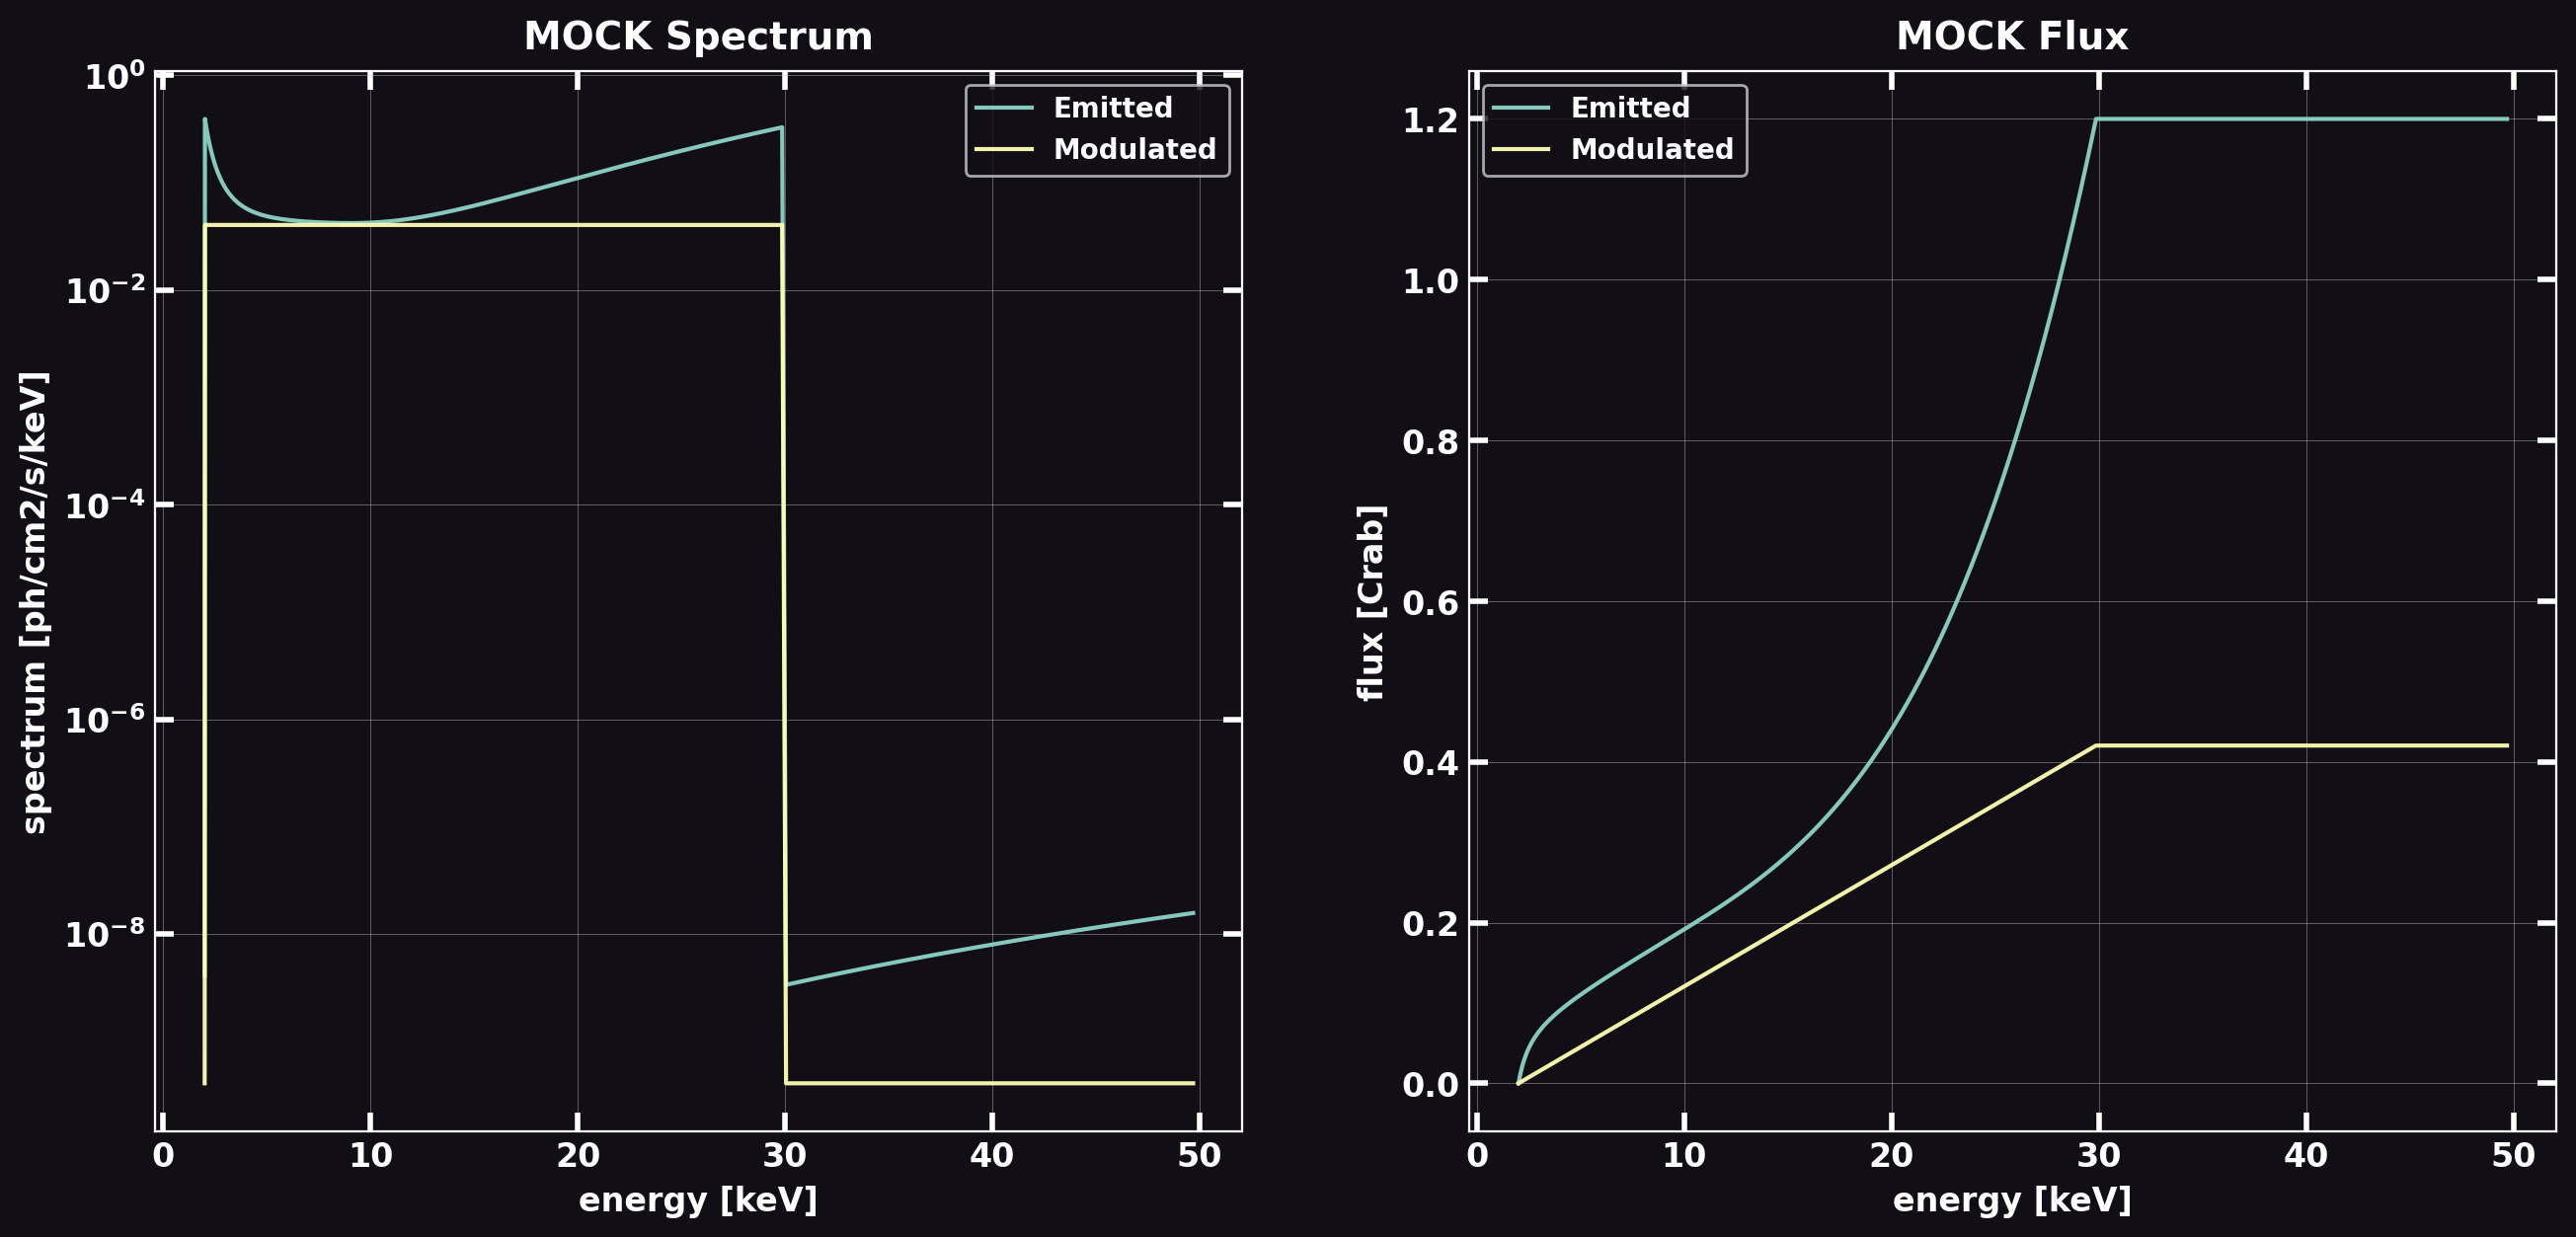

In [22]:
d_ebin = 1.0  # [keV]

# verbose
_totflx = integrate_spectrum(mock_spectrum, energy_bins)
print(
    f'Input total flux: {_totflx / CRAB_AVGFLX:.4f} Crab ({_totflx:.4f} ph/cm2/s)\n'
    f'Out total counts: {compute_source_counts(wfm, coords, _totflx, exposure)} ph\n'
)
OBS_EBAND = ewin if ewin is not None else CAMERA_ACTIVE_RANGE
print(
    f'Energy range: {OBS_EBAND} keV at {coords} deg\n'
    f'  - Source obs avg flux: {avg_flux / CRAB_AVGFLX:.4f} Crab ({avg_flux:.4f} ph/cm2/s)\n'
    f'  - Source obs counts in {exposure/1e3} ks: {counts} +/- {int(np.sqrt(counts))} ph\n'
)

d_obs_cts = (counts * d_ebin / np.diff(OBS_EBAND))[0] 
print(
    f'Source obs counts in {d_ebin} keV (for uniform obs spectr): {int(d_obs_cts)} +/- {int(np.sqrt(d_obs_cts))} ph'
)

ds.plot(
    dmaps=(
        ds.map4plot(
            arrs=(mock_spectrum, obs_spectrum),
            title=f'{sourceID.upper()} Spectrum',
            x=energy_bins[:-1],
            xlabel='energy [keV]',
            ylabel='spectrum [ph/cm2/s/keV]',
            labels=('Emitted', 'Modulated'),
            #xscale='log',
            yscale='log',
        ),
        ds.map4plot(
            arrs=(
                np.cumsum(mock_spectrum * np.diff(energy_bins)) / CRAB_AVGFLX,
                np.cumsum(obs_spectrum * np.diff(energy_bins)) / CRAB_AVGFLX,
            ),
            title=f'{sourceID.upper()} Flux',
            x=energy_bins[:-1],
            xlabel='energy [keV]',
            ylabel='flux [Crab]',
            labels=('Emitted', 'Modulated'),
        ),
    ),
    ncols=2,
    #save_to=ds.savefile_to(
    #    base_path,
    #    f'mockSource__{coords[0]}-{coords[1]}deg__{ewin[0]}-{ewin[1]}keV',
    #),
)

- Let's create the mock catalogue with the sources

Total # of sources: 30
Total flux from sources: 52.700 Crab



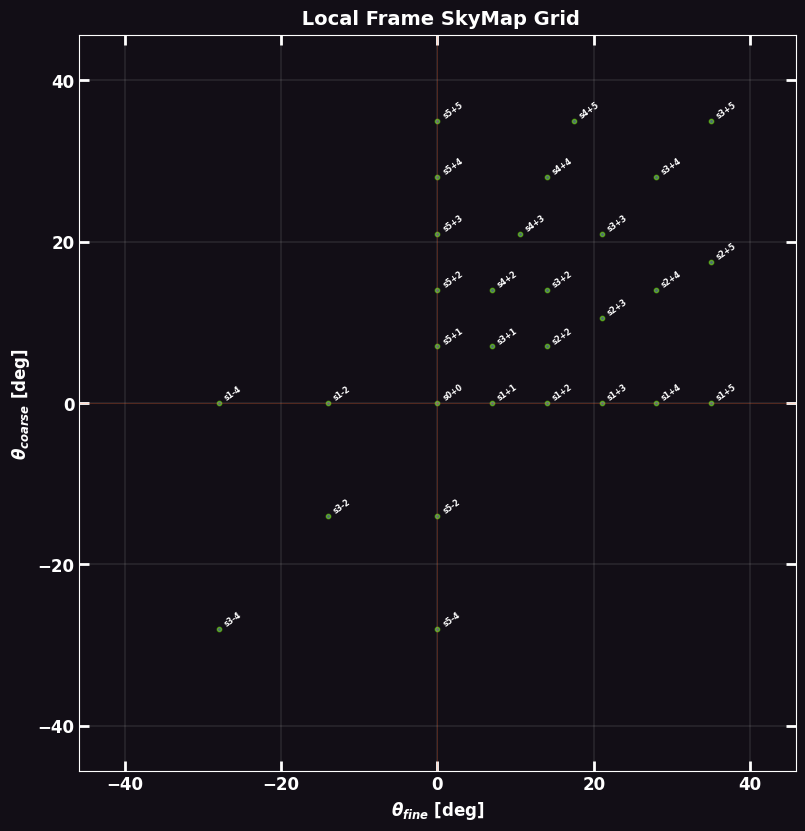

In [ ]:
from darksun.data import Log
import wmsims as wm
from wmsims.fields import Source

SAVE_TO: str = '/mnt/d/PhD_AASS/Coding/Images_fits'
# SAVE_TO: str = '/home/edoardo/Desktop'
SAVE_SKYFIELD: bool = False

srcs: tuple[Source, ...] = (
    # on-axis
    Source('s0+0', 0.0, 0.0, 1.1),
    # x-axis
    Source('s1+1', 7.0, 0.0, 1.1),
    Source('s1+2', 14.0, 0.0, 1.1),
    Source('s1+3', 21.0, 0.0, 1.5),
    Source('s1+4', 28.0, 0.0, 2.2),
    Source('s1+5', 35.0, 0.0, 2.4),
    Source('s1-2', -14.0, 0.0, 1.1),
    Source('s1-4', -28.0, 0.0, 2.2),
    # y-axis
    Source('s5+1', 0.0, 7.0, 1.1),
    Source('s5+2', 0.0, 14.0, 1.1),
    Source('s5+3', 0.0, 21.0, 1.3),
    Source('s5+4', 0.0, 28.0, 1.6),
    Source('s5+5', 0.0, 35.0, 2.1),
    Source('s5-2', 0.0, -14.0, 1.1),
    Source('s5-4', 0.0, -28.0, 1.6),
    # 45deg-diagonal
    Source('s3+1', 7.0, 7.0, 1.1),
    Source('s3+2', 14.0, 14.0, 1.1),
    Source('s3+3', 21.0, 21.0, 1.7),
    Source('s3+4', 28.0, 28.0, 3.4),
    Source('s3+5', 35.0, 35.0, 4.6),
    Source('s3-2', -14.0, -14.0, 1.1),
    Source('s3-4', -28.0, -28.0, 3.4),
    # 30deg-diagonal
    Source('s2+2', 14.0, 7.0, 1.1),
    Source('s2+3', 21.0, 10.5, 1.4),
    Source('s2+4', 28.0, 14.0, 2.1),
    Source('s2+5', 35.0, 17.5, 2.5),
    # 60deg-diagonal
    Source('s4+2', 7.0, 14.0, 1.1),
    Source('s4+3', 10.5, 21.0, 1.3),
    Source('s4+4', 14.0, 28.0, 1.7),
    Source('s4+5', 17.5, 35.0, 2.5),
)

log: Log = wm.gen_data_log(srcs)

print(
    f"Total # of sources: {len(srcs)}\n"
    f"Total flux from sources: {sum(tuple(src.flux for src in srcs)):.3f} Crab\n"
)
ds.skyfield_map(
    log=log,
    camera=wfm,
    show_IDs=True,
    save_to=(
        ds.savefile_to(SAVE_TO, 'instr_effects_mock_skyfield', overwrite=True)
        if SAVE_SKYFIELD else None
    ),
)

In [53]:
from typing import NamedTuple
from astropy.table import Table
from astropy.io.fits import BinTableHDU
from bloodmoon.types import CoordEquatorial
from bloodmoon.coords import shift2equatorial
from wmsims.fields import CameraPointer

class CatalogueEntry(NamedTuple):
    """Catalogue entries data for mock sources."""
    ID: str
    name: str
    ra: float
    dec: float
    avg_flux: float
    code: int
    formula: str
    index: float
    nh: float
    energy: NDArray
    spectrum: NDArray


def gen_mock_srcs_table(
    camera: CodedMaskCamera,
    sdl: CameraPointer,
    sources: Source | tuple[Source, ...],
    verbose: bool = False,
    show_plot: bool = False,
    #save_to: str | Path | None = None,
) -> Table:
    """
    Generates a table with entries relative to simulated mock sources.
    """
    def angle2equatorial(anglex: float, angley: float) -> CoordEquatorial:
        """Converts camera local-frame angular coords in RA/Dec coords."""
        sx, sy = map(lambda x: angle2shift(camera, x), (anglex, angley))
        return shift2equatorial(sdl, camera, sx, sy)
    
    entries: list[CatalogueEntry] = []
    srcs = (sources,) if isinstance(sources, Source) else sources
    catalogue: FITS_rec = load_fits_data(catalogue_path)
    energy_bins, _ = extract_spectrum(catalogue, 'crab')

    # hyperparams
    CRAB_AVGFLX: float = 2.7                        # [ph/cm2/s]
    EWIN: EnergyRange | None = (2.0, 30.0)          # energy window for emitted spectrum [keV]
    EXPOSURE: float = 1e4                           # [s]
    D_EBIN = 1.0                                    # [keV]
    FORMULA: str = 'power_law'
    PARAMS: tuple = (1.0, 0.0)

    for src in srcs:
        coords: AngularCoords = (src.angle_x, src.angle_y)
        # compute mock spectrum
        template = get_mock_spectrum(energy_bins, *PARAMS, ewin=EWIN, model_type=FORMULA)
        tsfunc: NDArray = compute_instr_transfer_func(energy_bins, coords)

        norm = src.flux * CRAB_AVGFLX
        mock_spectrum: NDArray = norm * template / tsfunc / integrate_spectrum(template / tsfunc, energy_bins)
        mock_avg_flux = integrate_spectrum(mock_spectrum, energy_bins)

        # compute obs avg_flux and obs cts
        obs_spectrum: NDArray = mock_spectrum * tsfunc
        avg_flux: float = integrate_spectrum(obs_spectrum, energy_bins)   # [ph/cm2/s]
        counts: int = compute_source_counts(camera, coords, avg_flux, EXPOSURE)

        # verbose
        if verbose:
            print(f'#### SOURCE {src.ID}')
            print(
                f'  Input total flux: {mock_avg_flux / CRAB_AVGFLX:.4f} Crab ({mock_avg_flux:.4f} ph/cm2/s)\n'
                f'  Out total counts: {compute_source_counts(camera, coords, mock_avg_flux, EXPOSURE)} ph\n'
            )
            print(
                f'  Energy range: {EWIN} keV at {coords} deg\n'
                f'    - Source obs avg flux: {avg_flux / CRAB_AVGFLX:.4f} Crab ({avg_flux:.4f} ph/cm2/s)\n'
                f'    - Source obs counts in {EXPOSURE/1e3} ks: {counts} +/- {int(np.sqrt(counts))} ph\n'
            )
            d_obs_cts = (counts * D_EBIN / np.diff(EWIN))[0] 
            print(
                f'  Source obs counts in {D_EBIN} keV (for uniform obs spectr): {int(d_obs_cts)} +/- {int(np.sqrt(d_obs_cts))} ph\n'
            )
        if show_plot:
            ds.plot(
                dmaps=(
                    ds.map4plot(
                        arrs=(mock_spectrum, obs_spectrum),
                        title=f'{src.ID.upper()} Spectrum',
                        x=energy_bins[:-1],
                        xlabel='energy [keV]',
                        ylabel='spectrum [ph/cm2/s/keV]',
                        labels=('Emitted', 'Modulated'),
                        yscale='log',
                    ),
                    ds.map4plot(
                        arrs=(
                            np.cumsum(mock_spectrum * np.diff(energy_bins)) / CRAB_AVGFLX,
                            np.cumsum(obs_spectrum * np.diff(energy_bins)) / CRAB_AVGFLX,
                        ),
                        title=f'{src.ID.upper()} Flux',
                        x=energy_bins[:-1],
                        xlabel='energy [keV]',
                        ylabel='flux [Crab]',
                        labels=('Emitted', 'Modulated'),
                    ),
                ),
                ncols=2,
                #save_to=(
                #    ds.savefile_to(save_to, f'mockSource__{coords[0]}-{coords[1]}deg__{ewin[0]}-{ewin[1]}keV')
                #    if save_to is not None else None
                #),
            )

        # define source entry
        nh = 0.1995259
        ra, dec = angle2equatorial(src.angle_x, src.angle_y)
        entry = CatalogueEntry(
            src.ID, src.ID, ra, dec, mock_avg_flux, 3, FORMULA, PARAMS[1], nh, energy_bins, mock_spectrum,
        )
        entries.append(entry)
    
    record = np.rec.array(
        obj=entries,
        dtype=[
            ('ID', '16U'), ('NAME', '20U'), ('RA', np.float32), ('DEC', np.float32), ('AVG_FLUX', np.float32),
            ('CODE', np.uint8), ('FORMULA', '16U'), ('INDEX', np.float32), ('NH', np.float32),
            ('ENERGY', np.float32, 513), ('SPECTRUM', np.float32, 512),
        ],
    )
    table: Table = Table(
        data=record,
        units=('', '', 'deg', 'deg', 'ph.s-1.cm-2', '', '', '', '', 'keV', 'ph.s-1.cm-2.keV-1'),
    )
    return table

def save_mock_data(data: Table, save_to: str | Path) -> None:
    """Saves mock sources catalogue to FITS file."""
    print("# Saving data...")
    # HDU list and Primary Header
    hdu_list = fits.HDUList([])
    primary_hdu = fits.PrimaryHDU()
    hdu_list.append(primary_hdu)
    # BinTable
    table_hdu = BinTableHDU(
        data=data,
        name='SOURCES',
    )
    hdu_list.append(table_hdu)
    # save data
    hdu_list.writeto(save_to, output_verify="fix+ignore")
    hdu_list.close()
    print("# Saving completed!")
    return None

In [54]:
sdl: CameraPointer = wm.define_unit_pointings(
    z_axis_RA=266.4,
    z_axis_DEC=-28.94,
    x_axis_RA=266.4,
    x_axis_DEC=61.06,
)
verbose: bool = True
show_plot: bool = False

table: Table = gen_mock_srcs_table(wfm, sdl, srcs, verbose=verbose, show_plot=show_plot)

table

#### SOURCE s0+0
  Input total flux: 1.1000 Crab (2.9700 ph/cm2/s)
  Out total counts: 2114491 ph

  Energy range: (2.0, 30.0) keV at (0.0, 0.0) deg
    - Source obs avg flux: 0.3713 Crab (1.0024 ph/cm2/s)
    - Source obs counts in 10.0 ks: 713651 +/- 844 ph

  Source obs counts in 1.0 keV (for uniform obs spectr): 25487 +/- 159 ph

#### SOURCE s1+1
  Input total flux: 1.1000 Crab (2.9700 ph/cm2/s)
  Out total counts: 2006760 ph

  Energy range: (2.0, 30.0) keV at (7.0, 0.0) deg
    - Source obs avg flux: 0.3730 Crab (1.0070 ph/cm2/s)
    - Source obs counts in 10.0 ks: 680396 +/- 824 ph

  Source obs counts in 1.0 keV (for uniform obs spectr): 24299 +/- 155 ph

#### SOURCE s1+2
  Input total flux: 1.1000 Crab (2.9700 ph/cm2/s)
  Out total counts: 2011494 ph

  Energy range: (2.0, 30.0) keV at (14.0, 0.0) deg
    - Source obs avg flux: 0.3781 Crab (1.0208 ph/cm2/s)
    - Source obs counts in 10.0 ks: 691385 +/- 831 ph

  Source obs counts in 1.0 keV (for uniform obs spectr): 24692 +/-

ID,NAME,RA,DEC,AVG_FLUX,CODE,FORMULA,INDEX,NH,ENERGY,SPECTRUM
,,deg,deg,ph / (s cm2),,,,,keV,ph / (keV s cm2)
str16,str20,float32,float32,float32,uint8,str16,float32,float32,float32[513],float32[512]
s0+0,s0+0,266.4,-28.94,2.97,3,power_law,0.0,0.1995259,2.0 .. 50.0,3.1404048e-09 .. 1.4695198e-08
s1+1,s1+1,266.4,-21.94,2.97,3,power_law,0.0,0.1995259,2.0 .. 50.0,3.206703e-09 .. 1.4654082e-08
s1+2,s1+2,266.4,-14.94,2.97,3,power_law,0.0,0.1995259,2.0 .. 50.0,3.4181846e-09 .. 1.452742e-08
s1+3,s1+3,266.4,-7.94,4.05,3,power_law,0.0,0.1995259,2.0 .. 50.0,5.2063225e-09 .. 1.9506196e-08
s1+4,s1+4,266.4,-0.94,5.94,3,power_law,0.0,0.1995259,2.0 .. 50.0,8.999758e-09 .. 2.792982e-08
s1+5,s1+5,266.4,6.06,6.48,3,power_law,0.0,0.1995259,2.0 .. 50.0,1.2350773e-08 .. 2.9394563e-08
s1-2,s1-2,266.4,-42.94,2.97,3,power_law,0.0,0.1995259,2.0 .. 50.0,3.4181846e-09 .. 1.452742e-08
s1-4,s1-4,266.4,-56.94,5.94,3,power_law,0.0,0.1995259,2.0 .. 50.0,8.999758e-09 .. 2.792982e-08


In [ ]:
SAVE_TO: str = '/mnt/d/PhD_AASS/Coding/Images_fits'
# SAVE_TO: str = '/home/edoardo/Desktop'
SAVE_CATALOGUE: bool = False

if SAVE_CATALOGUE:
    save_mock_data(table, ds.savefile_to(SAVE_TO, 'instr_effects_mock_catalogue_2-50keV', frmt='fits'))

# Saving data...
# Saving completed!
